<a href="https://colab.research.google.com/github/Lahari8447/Lahari8447-AggregateFunctions/blob/main/Copy_of_Untitled15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

project_dir = "/content/drive/MyDrive/aviation_project"
os.makedirs(project_dir, exist_ok=True)
print(f"Project folder created at: {project_dir}")


Project folder created at: /content/drive/MyDrive/aviation_project


In [ ]:
!pip install snowflake-connector-python snowflake-snowpark-python pyspark pycryptodome


  Using cached snowflake_connector_python-3.17.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (74 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.3/85.3 kB 7.3 MB/s eta 0:00:00
  Attempting uninstall: cloudpickle
    Found existing installation: cloudpickle 3.1.1
    Uninstalling cloudpickle-3.1.1:
      Successfully uninstalled cloudpickle-3.1.1


In [ ]:
import os

os.environ['SF_ACCOUNT']   = 'xy12345.ap-south-1.aws'   # from your URL
os.environ['SF_USER']      = 'lahariummadipolu@gmail.com'      # your Snowflake username/email
os.environ['SF_PASSWORD']  = 'Lahari@8447'
os.environ['SF_WAREHOUSE'] = 'WH_SMALL'
os.environ['SF_DATABASE']  = 'AVIATION_DB'
os.environ['SF_SCHEMA']    = 'RAW'


In [ ]:
import getpass, os

os.environ['SF_ACCOUNT']   = 'upetpad.ap-south-1.aws'  # from your Snowflake URL
os.environ['SF_USER']      = 'lahariummadipolu@gmail.com'
os.environ['SF_PASSWORD']  = getpass.getpass('Enter your Snowflake password: ')
os.environ['SF_WAREHOUSE'] = 'WH_SMALL'
os.environ['SF_DATABASE']  = 'AVIATION_DB'
os.environ['SF_SCHEMA']    = 'RAW'


Enter your Snowflake password: ··········


In [ ]:

import os, getpass

os.environ['SF_ACCOUNT']   = 'UPETPAD-TP15485'      # use the corrected account locator
os.environ['SF_USER']      = 'lahariummadipolu@gmail.com'
os.environ['SF_PASSWORD']  = getpass.getpass('Enter your Snowflake password: ')
os.environ['SF_WAREHOUSE'] = 'WH_SMALL'
os.environ['SF_DATABASE']  = 'AVIATION_DB'
os.environ['SF_SCHEMA']    = 'RAW'


Enter your Snowflake password: ··········


In [ ]:
import os
import getpass
import snowflake.connector

# === Set your Snowflake credentials ===
os.environ['SF_ACCOUNT']   = 'upetpad-tp15485'  # Only account locator, not full URL
os.environ['SF_USER']      = 'LAHARI'
os.environ['SF_PASSWORD']  = getpass.getpass('Enter your Snowflake password: ')
os.environ['SF_ROLE']      = 'ACCOUNTADMIN'
os.environ['SF_WAREHOUSE'] = 'WH_SMALL'     # Update if needed
os.environ['SF_DATABASE']  = 'AVIATION_DB'  # Update if needed
os.environ['SF_SCHEMA']    = 'RAW'          # Update if needed

# === Test the connection ===
try:
    con = snowflake.connector.connect(
        account=os.environ['SF_ACCOUNT'],
        user=os.environ['SF_USER'],
        password=os.environ['SF_PASSWORD'],
        role=os.environ['SF_ROLE'],
        warehouse=os.environ['SF_WAREHOUSE'],
        database=os.environ['SF_DATABASE'],
        schema=os.environ['SF_SCHEMA']
    )
    cur = con.cursor()
    cur.execute("SELECT CURRENT_TIMESTAMP();")
    print("Connection successful! Current time:", cur.fetchone()[0])
finally:
    try:
        cur.close()
    except:
        pass
    try:
        con.close()
    except:
        pass


Enter your Snowflake password: ··········
Connection successful! Current time: 2025-08-21 11:02:06.539000-07:00


In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

project_dir = "/content/drive/MyDrive/aviation_project"
data_dir = f"{project_dir}/data"
os.makedirs(data_dir, exist_ok=True)

print("Put your CSVs here:", data_dir)


Mounted at /content/drive
Put your CSVs here: /content/drive/MyDrive/aviation_project/data


In [ ]:
import os

data_dir = "/content/drive/MyDrive/aviation_project/data"
os.makedirs(data_dir, exist_ok=True)
print(f"Data folder ready at: {data_dir}")


Data folder ready at: /content/drive/MyDrive/aviation_project/data


In [ ]:
import pandas as pd

for file in files:
    print(f"\nPreview of {file}:")
    df = pd.read_csv(os.path.join(data_folder, file))
    print(df.head())


In [ ]:
import os

data_folder = "/content/drive/MyDrive/aviation_project/data"

# Create the folder if it doesn't exist
os.makedirs(data_folder, exist_ok=True)

print(f"Data folder ready at: {data_folder}")


Data folder ready at: /content/drive/MyDrive/aviation_project/data


In [ ]:

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
drive.flush_and_unmount()
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

data_folder = "/content/drive/MyDrive/aviation_project/data"

if os.path.exists(data_folder):
    print("Data folder found!")
    print("Contents:", os.listdir(data_folder))
else:
    print("Data folder not found! Please create it.")


Data folder found!
Contents: []


In [ ]:
import os
data_folder = "/content/drive/MyDrive/aviation_project/data"
print("Files in data folder:", os.listdir(data_folder))


Files in data folder: ['airlines.csv', 'airports.csv', 'flights_latest.csv', 'flights_sample.csv']


In [ ]:
import snowflake.connector
from getpass import getpass

# Enter your Snowflake credentials
con = snowflake.connector.connect(
    account="UPETPAD-TP15485",
    user="LAHARI",  # <-- Use this, not your email
    password=getpass("Enter your Snowflake password: "),
    warehouse="WH_SMALL",
    database="AVIATION_DB",
    schema="RAW",
    role="ACCOUNTADMIN"
)
cur = con.cursor()

# Test connection
cur.execute("SELECT CURRENT_TIMESTAMP();")
print("Connection successful! Current time:", cur.fetchone()[0])


Enter your Snowflake password: ··········
Connection successful! Current time: 2025-08-21 11:34:14.385000-07:00


In [ ]:
files = ['airlines.csv', 'airports.csv', 'flights_latest.csv', 'flights_sample.csv']
stage_name = 'stg_aviation'

for file in files:
    file_path = f"/content/drive/MyDrive/aviation_project/data/{file}"
    cur.execute(f"PUT file://{file_path} @{stage_name} AUTO_COMPRESS=TRUE OVERWRITE=TRUE")
    print(f"Uploaded: {file}")


Uploaded: airlines.csv
Uploaded: airports.csv
Uploaded: flights_latest.csv
Uploaded: flights_sample.csv


In [ ]:
cur.execute("""
COPY INTO dim_airlines
FROM @stg_aviation/airlines.csv.gz
FILE_FORMAT = (FORMAT_NAME = ff_csv)
ON_ERROR = 'CONTINUE';
""")
print("Loaded airlines.csv into dim_airlines")


Loaded airlines.csv into dim_airlines


In [ ]:
cur.execute("""
COPY INTO dim_airports
FROM @stg_aviation/airports.csv.gz
FILE_FORMAT = (FORMAT_NAME = ff_csv)
ON_ERROR = 'CONTINUE';
""")
print("Loaded airports.csv into dim_airports")


Loaded airports.csv into dim_airports


In [ ]:
cur.execute("""
COPY INTO fact_flights
FROM @stg_aviation/flights_sample.csv.gz
FILE_FORMAT = (FORMAT_NAME = ff_csv)
ON_ERROR = 'CONTINUE';
""")
print("Loaded flights_sample.csv into fact_flights")


Loaded flights_sample.csv into fact_flights


In [ ]:
cur.execute("SELECT COUNT(*) FROM dim_airlines;")
print("Rows in dim_airlines:", cur.fetchone()[0])

cur.execute("SELECT COUNT(*) FROM dim_airports;")
print("Rows in dim_airports:", cur.fetchone()[0])

cur.execute("SELECT COUNT(*) FROM fact_flights;")
print("Rows in fact_flights:", cur.fetchone()[0])


Rows in dim_airlines: 14
Rows in dim_airports: 322
Rows in fact_flights: 195


In [ ]:
cur.execute("""
COPY INTO fact_flights
FROM @stg_aviation/flights_latest.csv.gz
FILE_FORMAT = (FORMAT_NAME = ff_csv)
ON_ERROR = 'CONTINUE';
""")
print("Loaded flights_latest.csv into fact_flights")


Loaded flights_latest.csv into fact_flights


In [ ]:
cur.execute("""
SELECT AIRLINE, COUNT(*) AS total_flights
FROM fact_flights
GROUP BY AIRLINE
ORDER BY total_flights DESC
""")
for row in cur.fetchall():
    print(row)


('WN', 37)
('UA', 36)
('AA', 32)
('DL', 32)
('OO', 28)
('B6', 27)
('EV', 26)
('US', 24)
('AS', 13)
('NK', 12)
('MQ', 10)
('HA', 8)
('F9', 7)
('VX', 2)


In [ ]:
cur.execute("""
SELECT d.AIRLINE, COUNT(*) AS total_flights
FROM fact_flights f
JOIN dim_airlines d
ON f.AIRLINE = d.IATA_CODE
GROUP BY d.AIRLINE
ORDER BY total_flights DESC;
""")
for row in cur.fetchall():
    print(row)


('Southwest Airlines Co.', 37)
('United Air Lines Inc.', 36)
('American Airlines Inc.', 32)
('Delta Air Lines Inc.', 32)
('Skywest Airlines Inc.', 28)
('JetBlue Airways', 27)
('Atlantic Southeast Airlines', 26)
('US Airways Inc.', 24)
('Alaska Airlines Inc.', 13)
('Spirit Air Lines', 12)
('American Eagle Airlines Inc.', 10)
('Hawaiian Airlines Inc.', 8)
('Frontier Airlines Inc.', 7)
('Virgin America', 2)


In [ ]:
cur.execute("""
SELECT AIRLINE,
       AVG(ARRIVAL_DELAY) AS avg_arrival_delay,
       AVG(DEPARTURE_DELAY) AS avg_departure_delay
FROM fact_flights
GROUP BY AIRLINE
ORDER BY avg_arrival_delay DESC;
""")
for row in cur.fetchall():
    print(row)


('MQ', Decimal('8.000000'), Decimal('11.200000'))
('OO', Decimal('7.040000'), Decimal('6.440000'))
('AA', Decimal('4.548387'), Decimal('7.000000'))
('WN', Decimal('4.324324'), Decimal('10.432432'))
('UA', Decimal('3.527778'), Decimal('6.972222'))
('EV', Decimal('3.000000'), Decimal('6.653846'))
('B6', Decimal('2.185185'), Decimal('7.777778'))
('HA', Decimal('1.000000'), Decimal('-1.625000'))
('NK', Decimal('0.083333'), Decimal('4.916667'))
('US', Decimal('-2.708333'), Decimal('1.125000'))
('F9', Decimal('-2.714286'), Decimal('5.285714'))
('DL', Decimal('-5.656250'), Decimal('5.250000'))
('VX', Decimal('-7.500000'), Decimal('4.000000'))
('AS', Decimal('-16.833333'), Decimal('-7.333333'))


<Axes: xlabel='Airline'>

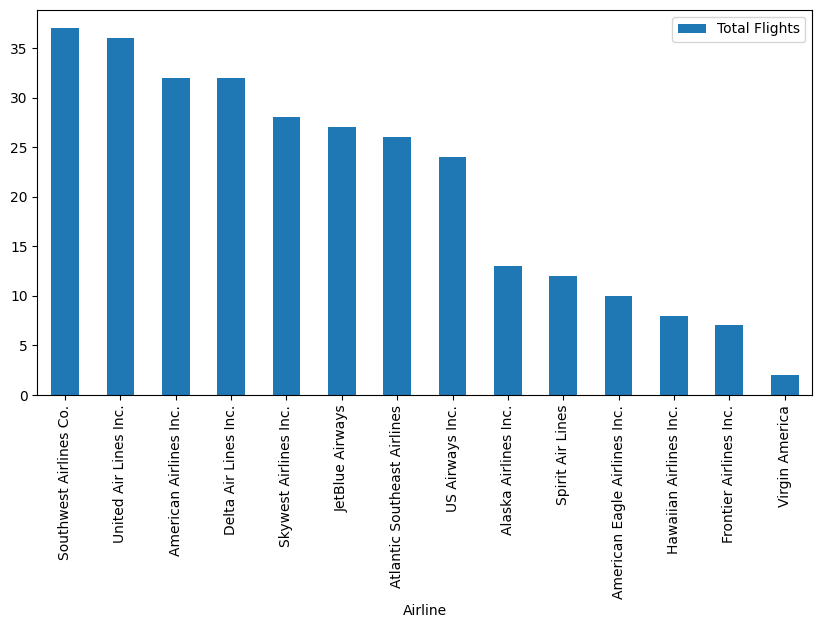

In [ ]:
import pandas as pd

query = """
SELECT d.AIRLINE, COUNT(*) AS total_flights
FROM fact_flights f
JOIN dim_airlines d
ON f.AIRLINE = d.IATA_CODE
GROUP BY d.AIRLINE
ORDER BY total_flights DESC;
"""
cur.execute(query)
df = pd.DataFrame(cur.fetchall(), columns=['Airline', 'Total Flights'])
df.plot(kind='bar', x='Airline', y='Total Flights', figsize=(10,5))


In [ ]:
cur.execute("""
SELECT d.AIRLINE, COUNT(*) AS total_flights
FROM fact_flights f
JOIN dim_airlines d
  ON f.AIRLINE = d.IATA_CODE
GROUP BY d.AIRLINE
ORDER BY total_flights DESC;
""")
print(cur.fetchall())


[('Southwest Airlines Co.', 37), ('United Air Lines Inc.', 36), ('American Airlines Inc.', 32), ('Delta Air Lines Inc.', 32), ('Skywest Airlines Inc.', 28), ('JetBlue Airways', 27), ('Atlantic Southeast Airlines', 26), ('US Airways Inc.', 24), ('Alaska Airlines Inc.', 13), ('Spirit Air Lines', 12), ('American Eagle Airlines Inc.', 10), ('Hawaiian Airlines Inc.', 8), ('Frontier Airlines Inc.', 7), ('Virgin America', 2)]


In [ ]:
cur.execute("""
SELECT d.AIRLINE,
       ROUND(AVG(f.ARRIVAL_DELAY),2) AS avg_arrival_delay,
       ROUND(AVG(f.DEPARTURE_DELAY),2) AS avg_departure_delay
FROM fact_flights f
JOIN dim_airlines d
  ON f.AIRLINE = d.IATA_CODE
GROUP BY d.AIRLINE
ORDER BY avg_arrival_delay DESC;
""")
print(cur.fetchall())


[('American Eagle Airlines Inc.', Decimal('8.00'), Decimal('11.20')), ('Skywest Airlines Inc.', Decimal('7.04'), Decimal('6.44')), ('American Airlines Inc.', Decimal('4.55'), Decimal('7.00')), ('Southwest Airlines Co.', Decimal('4.32'), Decimal('10.43')), ('United Air Lines Inc.', Decimal('3.53'), Decimal('6.97')), ('Atlantic Southeast Airlines', Decimal('3.00'), Decimal('6.65')), ('JetBlue Airways', Decimal('2.19'), Decimal('7.78')), ('Hawaiian Airlines Inc.', Decimal('1.00'), Decimal('-1.63')), ('Spirit Air Lines', Decimal('0.08'), Decimal('4.92')), ('US Airways Inc.', Decimal('-2.71'), Decimal('1.13')), ('Frontier Airlines Inc.', Decimal('-2.71'), Decimal('5.29')), ('Delta Air Lines Inc.', Decimal('-5.66'), Decimal('5.25')), ('Virgin America', Decimal('-7.50'), Decimal('4.00')), ('Alaska Airlines Inc.', Decimal('-16.83'), Decimal('-7.33'))]


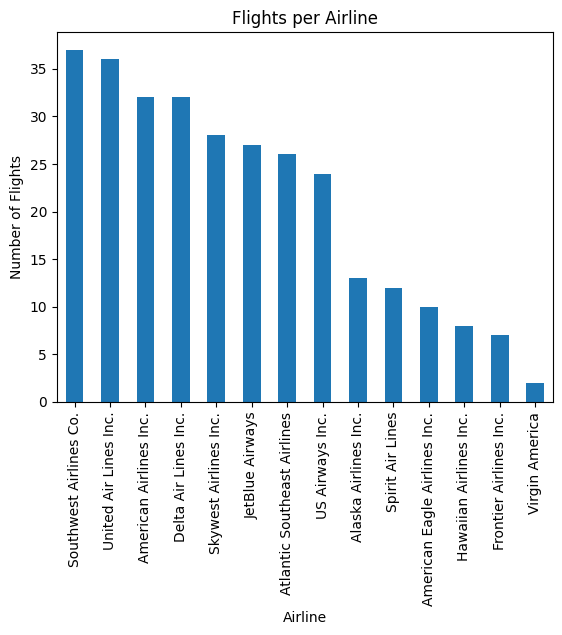

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

query = """
SELECT d.AIRLINE, COUNT(*) AS total_flights
FROM fact_flights f
JOIN dim_airlines d
  ON f.AIRLINE = d.IATA_CODE
GROUP BY d.AIRLINE
ORDER BY total_flights DESC;
"""
cur.execute(query)
df = pd.DataFrame(cur.fetchall(), columns=['Airline', 'Total Flights'])

df.plot(kind='bar', x='Airline', y='Total Flights', legend=False)
plt.title("Flights per Airline")
plt.ylabel("Number of Flights")
plt.show()


In [ ]:
from Crypto.Cipher import AES
import base64

key = b'1234567890ABCDEF'  # 16 bytes key
cipher = AES.new(key, AES.MODE_EAX)
ciphertext, tag = cipher.encrypt_and_digest(b"MySecretData")
encoded = base64.b64encode(ciphertext).decode()
print("Encrypted:", encoded)


Encrypted: Mq3rq2qVdpxmy6ey


In [ ]:
from Crypto.Cipher import AES
import base64
import pandas as pd
from Crypto.Random import get_random_bytes

# Load flights data
df = pd.read_csv("/content/drive/MyDrive/aviation_project/data/flights_sample.csv")

# AES key (keep this secret and consistent)
key = b'1234567890ABCDEF'  # 16 bytes for AES-128

def encrypt_text(text):
    if pd.isna(text):  # handle missing values
        return None
    cipher = AES.new(key, AES.MODE_EAX)  # new cipher for each encryption
    ciphertext, tag = cipher.encrypt_and_digest(str(text).encode())
    return base64.b64encode(cipher.nonce + ciphertext).decode()  # store nonce + ciphertext

# Encrypt the TAIL_NUMBER column
df['TAIL_NUMBER'] = df['TAIL_NUMBER'].apply(encrypt_text)

# Save encrypted file
encrypted_path = "/content/drive/MyDrive/aviation_project/data/flights_encrypted.csv"
df.to_csv(encrypted_path, index=False)
print(f"Encrypted data saved at: {encrypted_path}")


Encrypted data saved at: /content/drive/MyDrive/aviation_project/data/flights_encrypted.csv


In [ ]:
encrypted_file = "/content/drive/MyDrive/aviation_project/data/flights_encrypted.csv"

cur.execute(f"""
PUT file://{encrypted_file} @stg_aviation AUTO_COMPRESS=TRUE OVERWRITE=TRUE;
""")
print("Encrypted file uploaded to stage!")


Encrypted file uploaded to stage!


In [ ]:
cur.execute("""
COPY INTO fact_flights
FROM @stg_aviation/flights_encrypted.csv.gz
FILE_FORMAT = (FORMAT_NAME = ff_csv)
ON_ERROR = 'CONTINUE';
""")
print("Encrypted flights data loaded into fact_flights!")


Encrypted flights data loaded into fact_flights!


In [ ]:
cur.execute("SELECT COUNT(*) FROM fact_flights;")
print("Rows in fact_flights:", cur.fetchone()[0])


Rows in fact_flights: 489


In [ ]:
for file in ["flights_encrypted.csv"]:
    file_path = f"/content/drive/MyDrive/aviation_project/data/{file}"
    cur.execute(f"PUT file://{file_path} @stg_aviation AUTO_COMPRESS=TRUE OVERWRITE=TRUE")


In [ ]:
import pandas as pd

query = """
SELECT * FROM gold.monthly_airline_delays;
"""
cur.execute(query)
df_gold = cur.fetch_pandas_all()
print(df_gold.head())


   YEAR  MONTH                 AIRLINE  AVG_ARRIVAL_DELAY  TOTAL_FLIGHTS
0  2015      1    Alaska Airlines Inc.         -15.687500             35
1  2015      1  American Airlines Inc.           7.563380             74
2  2015      1         US Airways Inc.          -2.250000             52
3  2015      1    Delta Air Lines Inc.          -3.453125             64
4  2015      1        Spirit Air Lines           0.083333             36


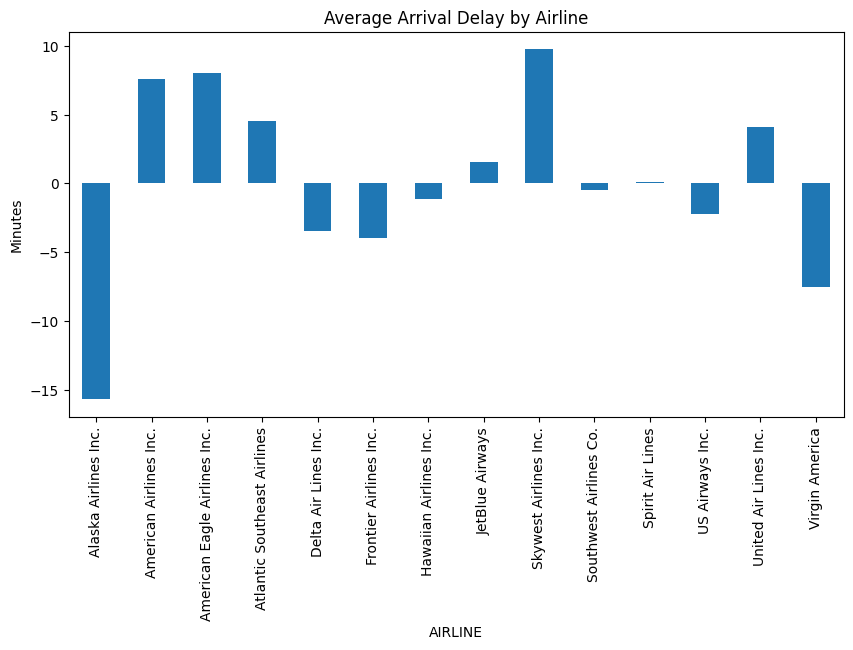

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

query = """
SELECT YEAR, MONTH, AIRLINE, total_flights, avg_arrival_delay
FROM gold.monthly_airline_delays
"""
cur.execute(query)
df = cur.fetch_pandas_all()

# Example: Average delay by airline
avg_delay_by_airline = df.groupby('AIRLINE')['AVG_ARRIVAL_DELAY'].mean()
avg_delay_by_airline.plot(kind='bar', figsize=(10,5))
plt.title("Average Arrival Delay by Airline")
plt.ylabel("Minutes")
plt.show()


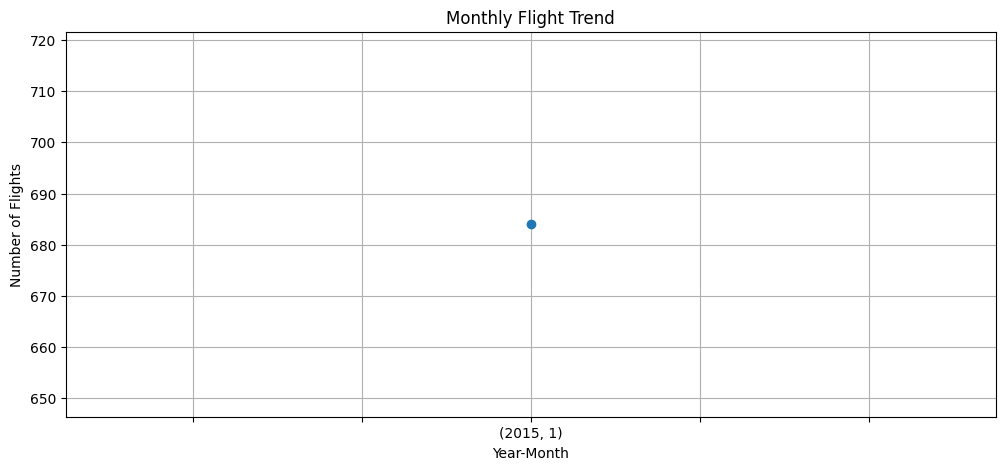

In [ ]:
#Create More Visualizations



#Flights per month (trend over time)

flights_per_month = df.groupby(['YEAR','MONTH'])['TOTAL_FLIGHTS'].sum()
flights_per_month.plot(kind='line', figsize=(12,5), marker='o')
plt.title("Monthly Flight Trend")
plt.ylabel("Number of Flights")
plt.xlabel("Year-Month")
plt.grid()
plt.show()

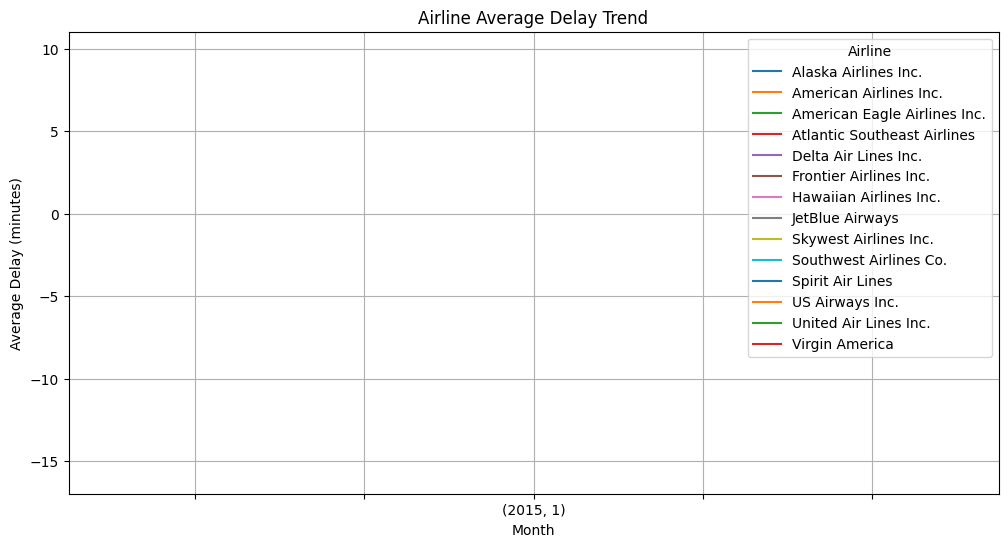

In [ ]:
#Airlines with highest delays over time

airline_delays = df.groupby(['YEAR','MONTH','AIRLINE'])['AVG_ARRIVAL_DELAY'].mean().unstack()
airline_delays.plot(figsize=(12,6))
plt.title("Airline Average Delay Trend")
plt.ylabel("Average Delay (minutes)")
plt.xlabel("Month")
plt.legend(title="Airline")
plt.grid()
plt.show()

In [ ]:
#3. Export Final Results

#Save visualizations as .png or .pdf.

#Export Gold layer to a CSV for sharing:

df.to_csv("/content/drive/MyDrive/aviation_project/gold_monthly_delays.csv", index=False)

In [ ]:
#Export Final Results
#1. Export GOLD Layer to CSV

#This creates a sharable version of your analytics-ready data.

# Save GOLD layer dataframe as CSV
df.to_csv("/content/drive/MyDrive/aviation_project/gold_monthly_delays.csv", index=False)
print("Gold layer exported to: /content/drive/MyDrive/aviation_project/gold_monthly_delays.csv")

Gold layer exported to: /content/drive/MyDrive/aviation_project/gold_monthly_delays.csv


Visualization saved as PNG.


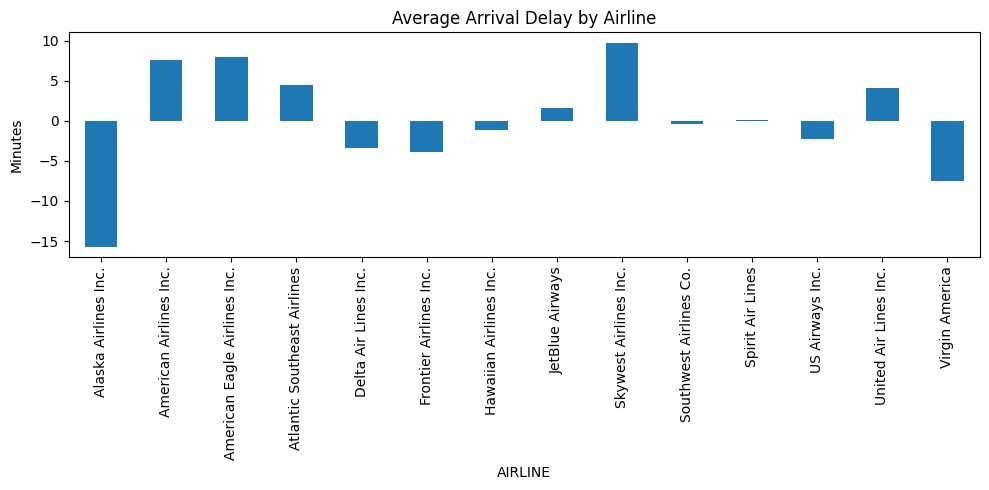

In [ ]:
#2. Export Visualizations as PNG

#If you already have a figure (like your delay bar chart), save it:

plt.figure(figsize=(10,5))
avg_delay_by_airline.plot(kind='bar')
plt.title("Average Arrival Delay by Airline")
plt.ylabel("Minutes")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/aviation_project/avg_delay_by_airline.png")
print("Visualization saved as PNG.")